# Basic Visualizations and Descriptive Statistics of Spike Train Data


## Load the spike train data


In [1]:
load('Ch8-spikes-1.mat')


ans = '/Users/Jie/Documents/Richard/Reference/Notes/notes_on_kramer_case_studies_neural_data_analysis/Case-Studies-Kramer-Eden/Chapter8'

## Step 1


In [2]:
size(SpikesLow)

T = 30; %The duration of the recording in seconds,
n = size(SpikesLow, 2); %...and # spikes in low light condition,
f = n / T; %... to compute the firing rate.


ans = 1x2 double
     1   750

### Figure 8.1


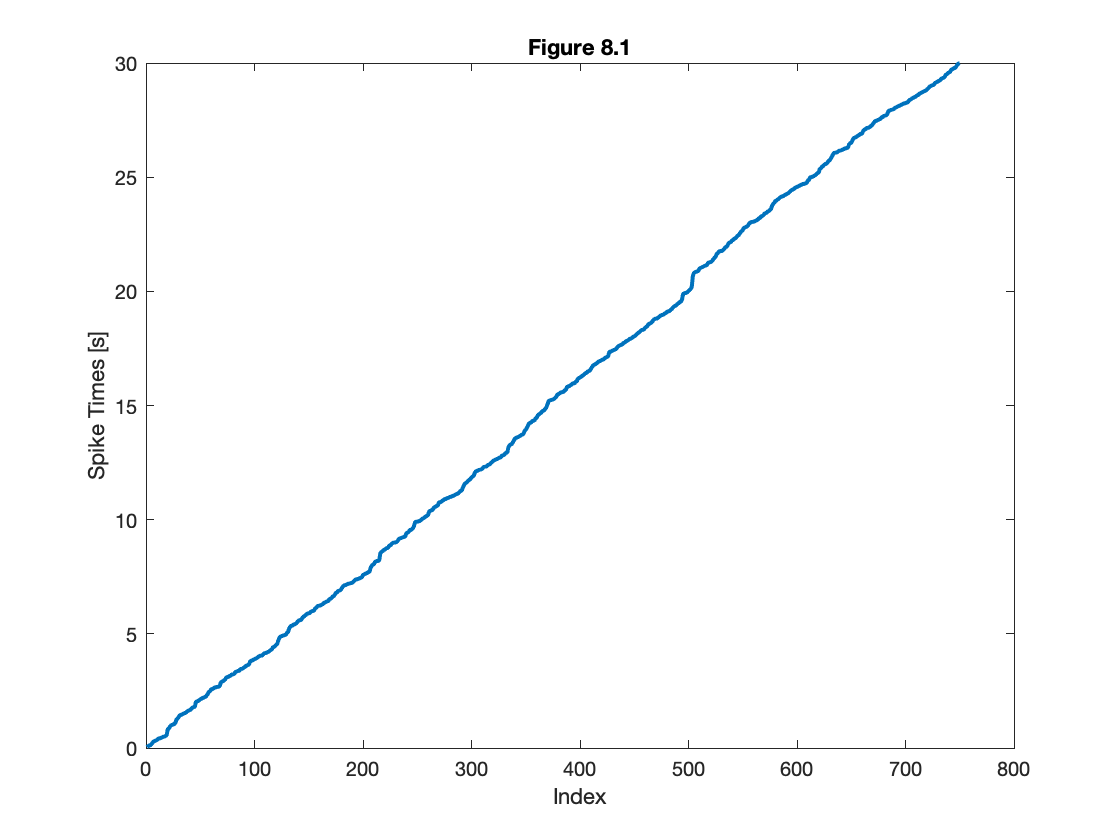

In [7]:
figure
plot(SpikesLow, 'LineWidth', 2)
xlabel('Index')
ylabel('Spike Times [s]')
title('Figure 8.1')


### Figure 8.2


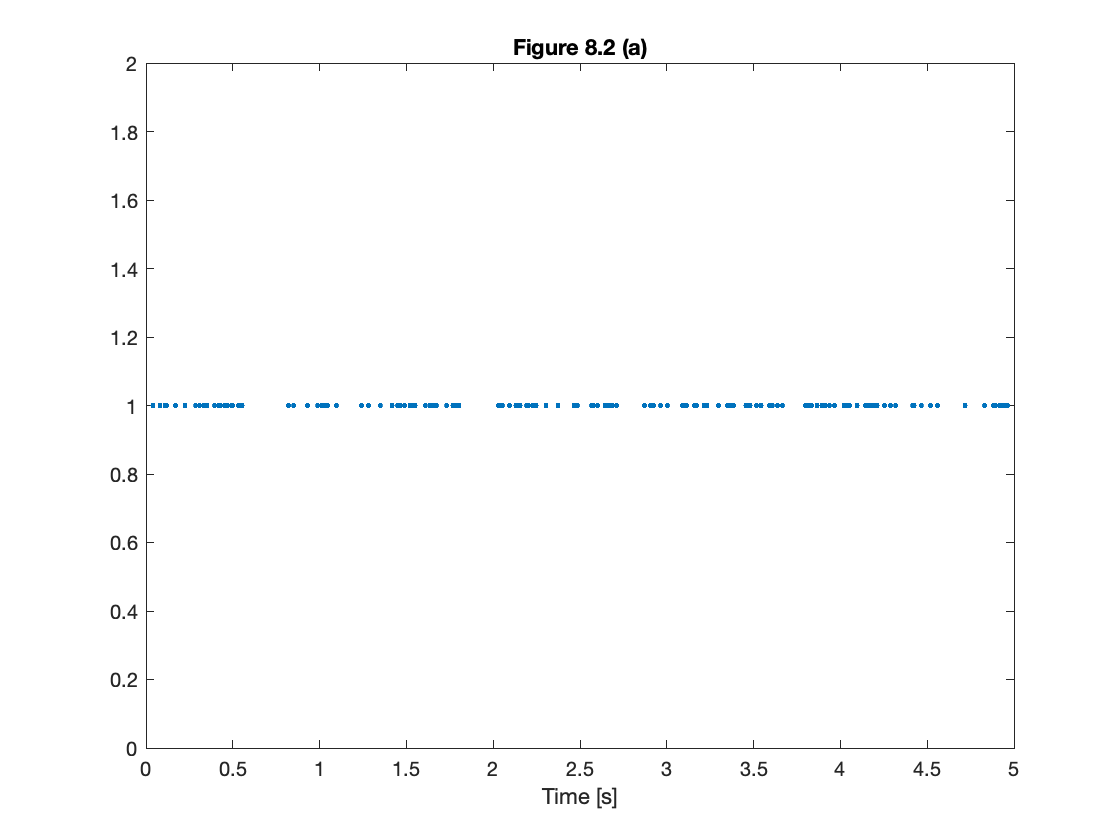

In [9]:
figure
plot(SpikesLow, ones(size(SpikesLow)), '.'); %Plot spikes as a row,
xlim([0 5]); %...display times (0,5)s,
xlabel('Time [s]') %...label the x-axis.
title('Figure 8.2 (a)')


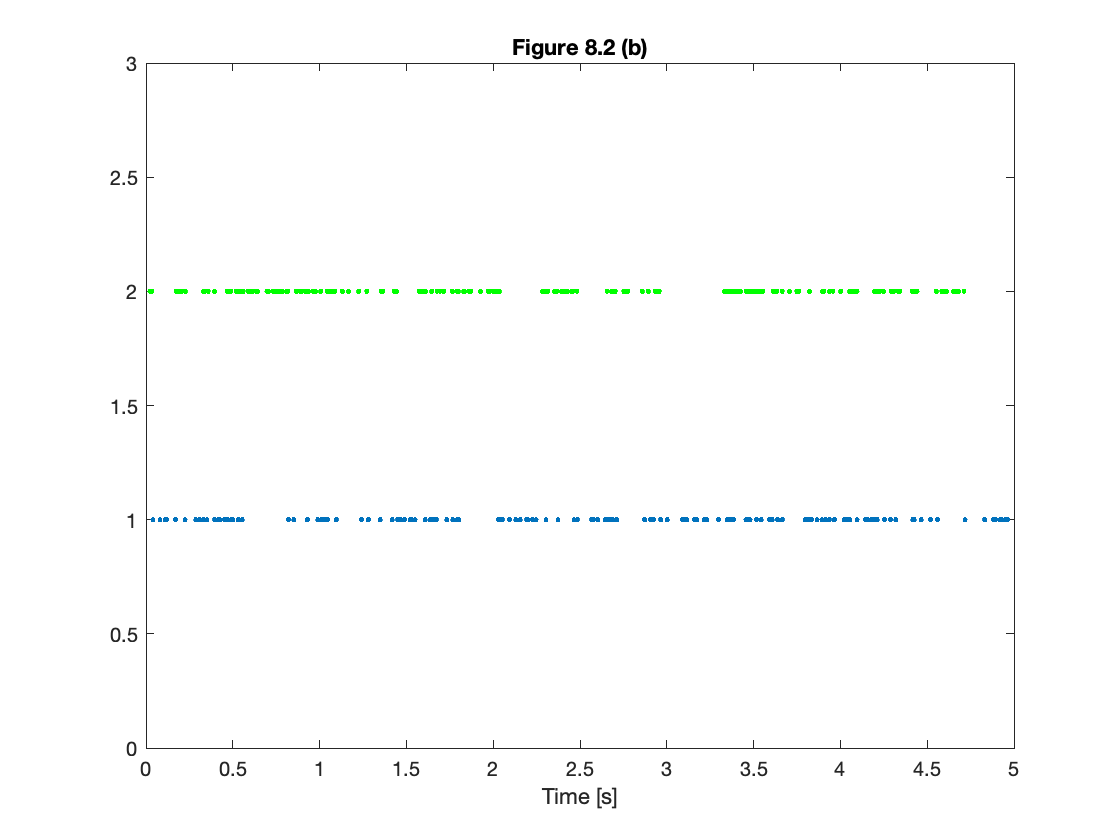

In [10]:
figure
% Plot low light condition spikes:
plot(SpikesLow, ones(size(SpikesLow)), '.');
hold on %... freeze the graphics window.
% Plot high light condition spikes:
plot(SpikesHigh, 2 * ones(size(SpikesHigh)), '.g');
hold off %... release the graphics window,
xlim([0 5]); %... and display times 0 to 5 s,
ylim([0 3]); %... set y-axis range,
xlabel('Time [s]') %... and label the x-axis.
title('Figure 8.2 (b)')


### Figure 8.3


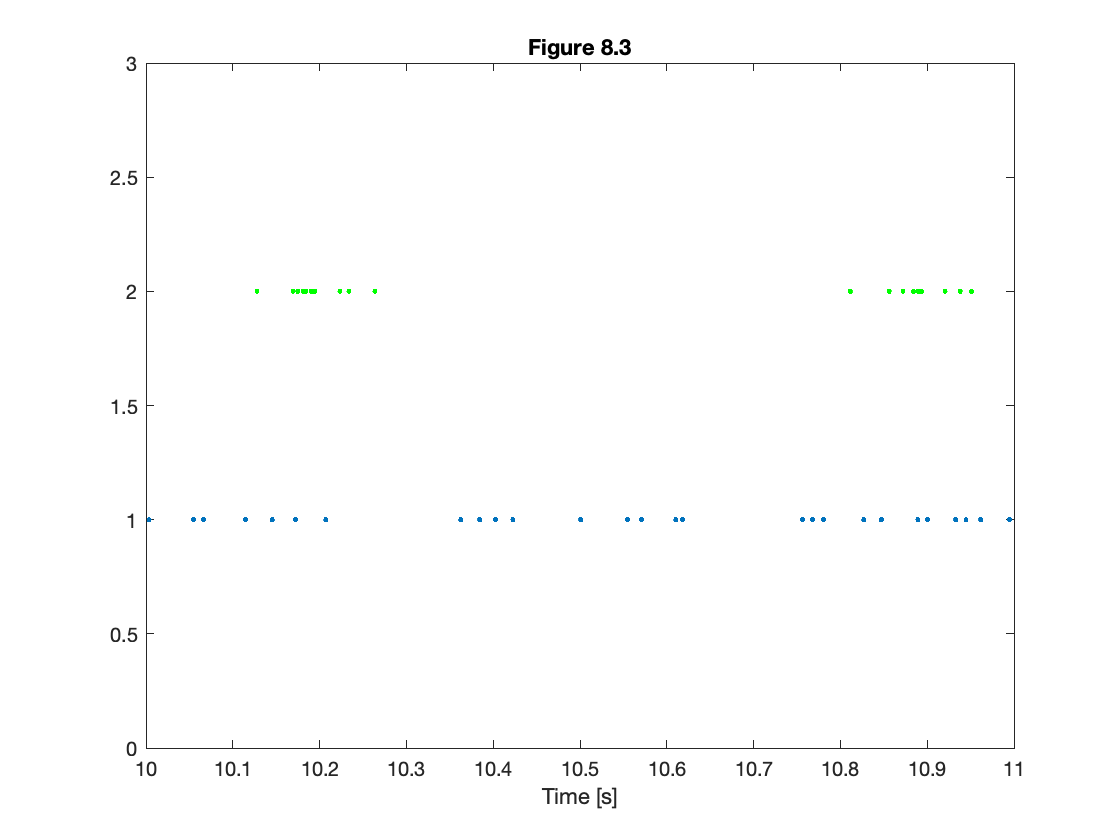

In [12]:
figure
% Plot low light condition spikes:
plot(SpikesLow, ones(size(SpikesLow)), '.');
hold on %... freeze the graphics window.
% Plot high light condition spikes:
plot(SpikesHigh, 2 * ones(size(SpikesHigh)), '.g');
hold off %... release the graphics window,
xlim([10 11]); %... and display times 0 to 5 s,
ylim([0 3]); %... set y-axis range,
xlabel('Time [s]') %... and label the x-axis.
title('Figure 8.3')


## Step 2


In [16]:
ISIsLow = diff(SpikesLow); %Compute ISIs in low light condition.
ISIsHigh = diff(SpikesHigh); %Compute ISIs in high light condition.


### Figure 8.4


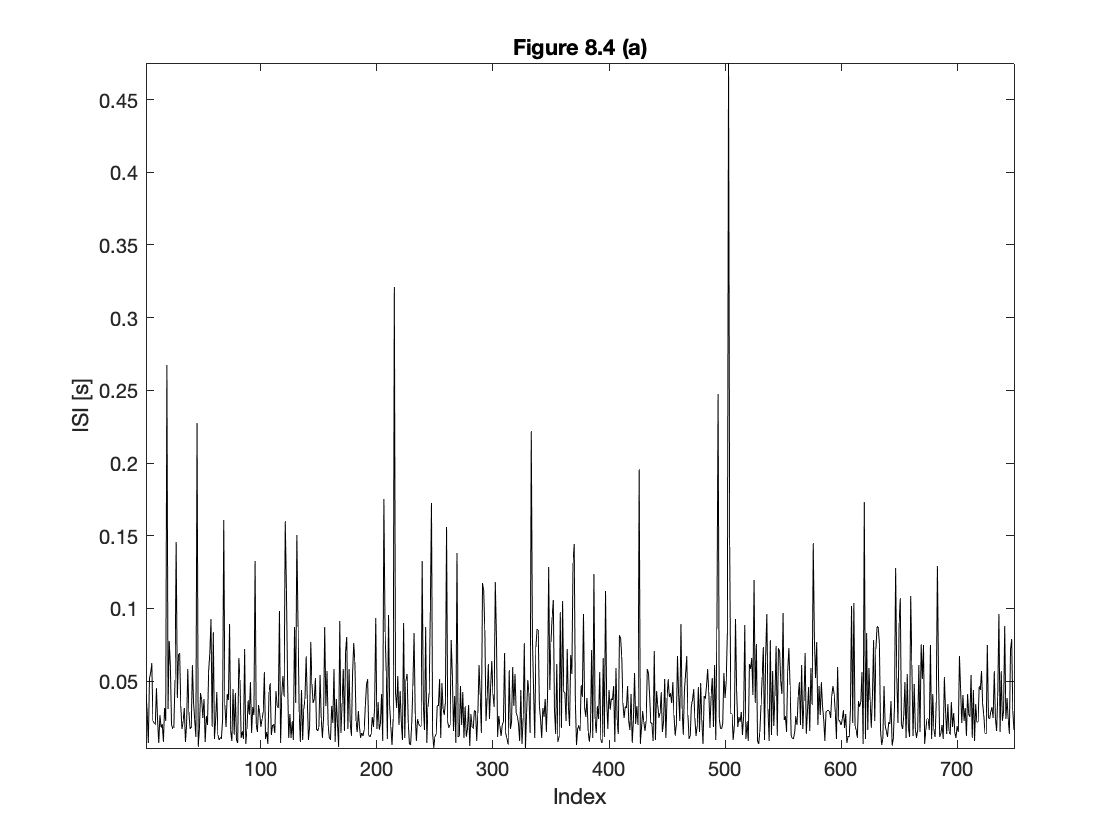

In [25]:
figure
plot(ISIsLow, 'k')
axis tight
xlabel('Index')
ylabel('ISI [s]')
title('Figure 8.4 (a)')


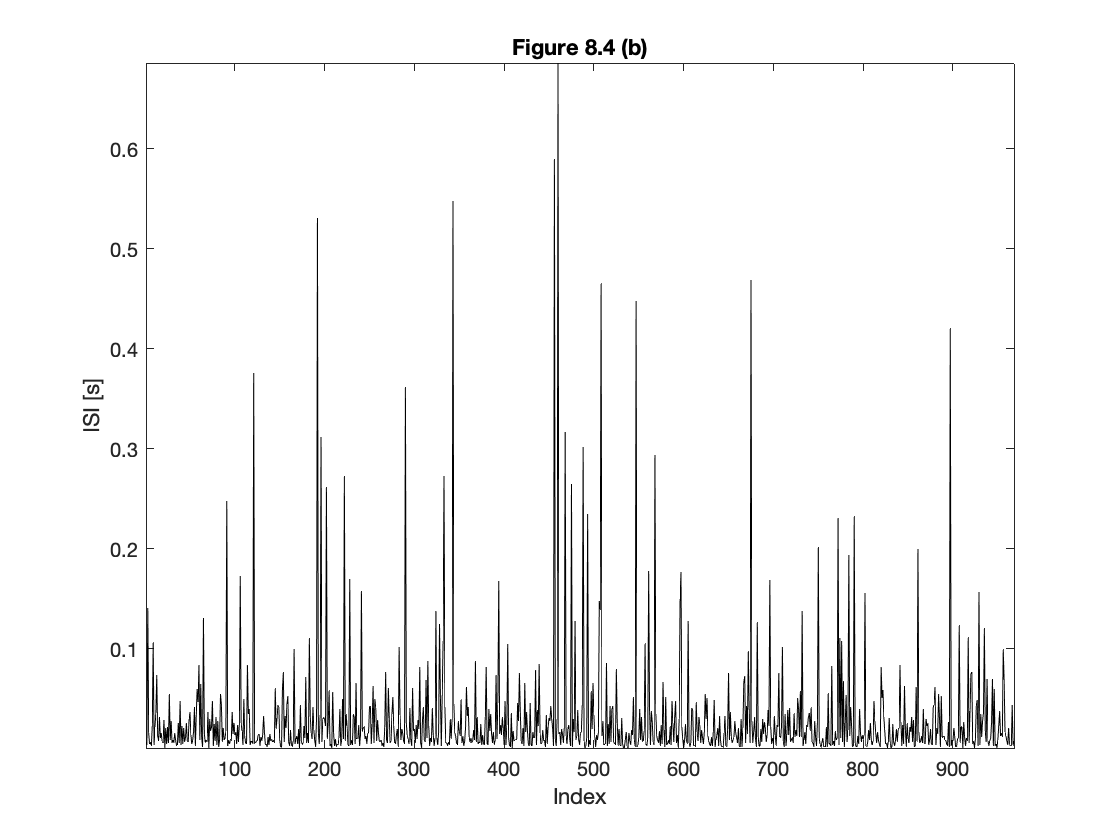

In [24]:
figure
plot(ISIsHigh, 'k')
axis tight
xlabel('Index')
ylabel('ISI [s]')
title('Figure 8.4 (b)')


### Figure 8.5


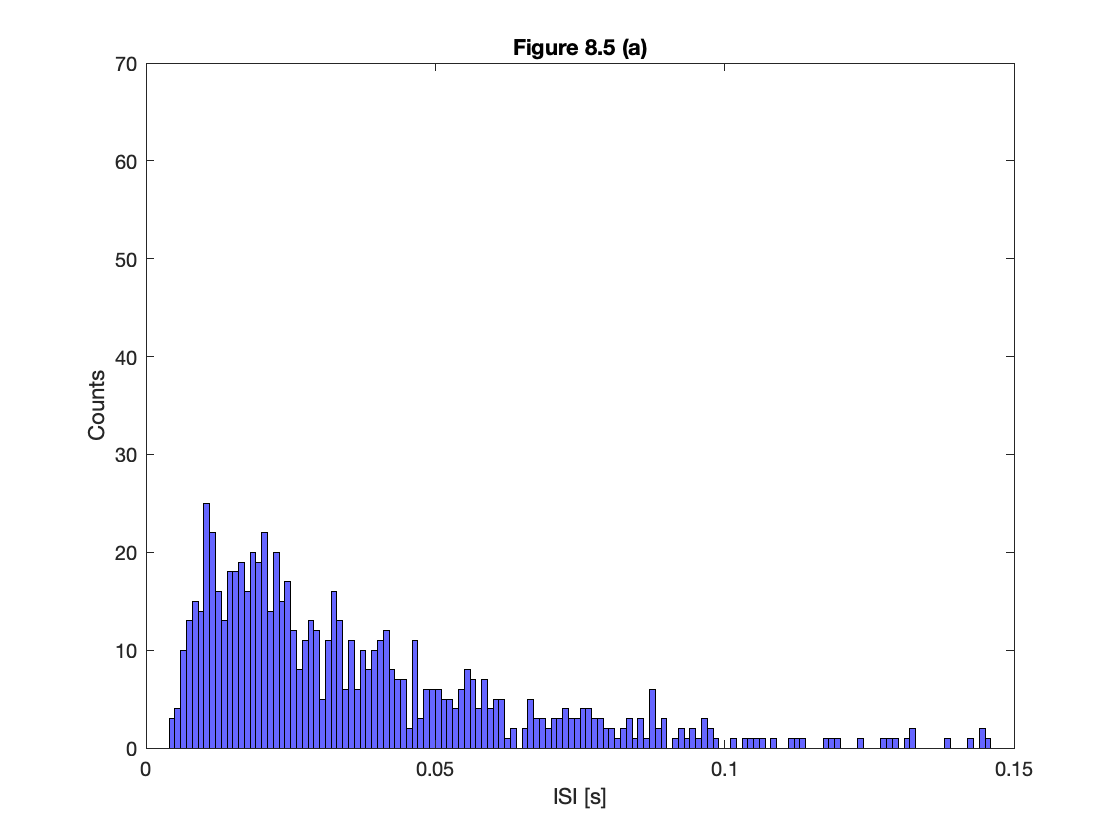

In [21]:
bins = (0:0.001:0.5); %Define the bins for the histogram.

figure
histogram(ISIsLow, bins, 'FaceColor', 'b') %Plot the histogram of the ISI data,
xlim([0 0.15]) %... focus on ISIs from 0 to 150 ms,
ylim([0 70])
xlabel('ISI [s]') %... label the x-axis,
ylabel('Counts') %... and the y-axis.
title('Figure 8.5 (a)')


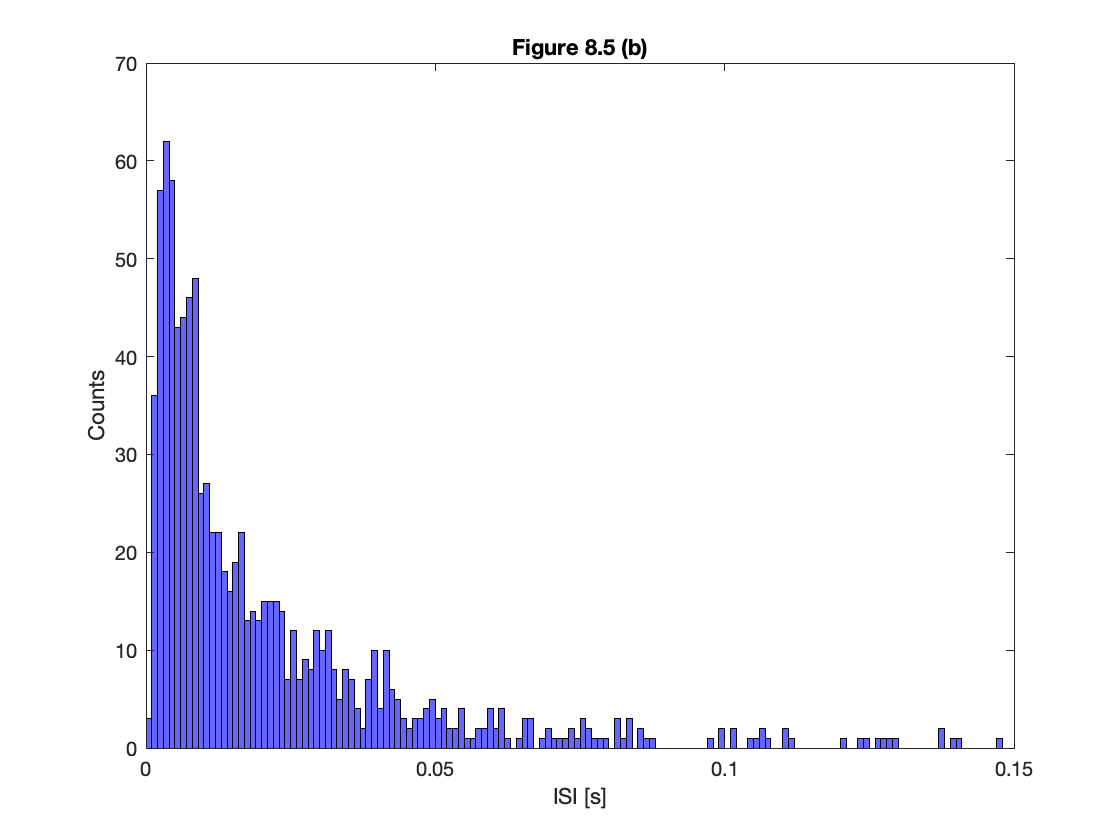

In [26]:
bins = (0:0.001:0.5); %Define the bins for the histogram.

figure
histogram(ISIsHigh, bins, 'FaceColor', 'b') %Plot the histogram of the ISI data,
xlim([0 0.15]) %... focus on ISIs from 0 to 150 ms,
ylim([0 70])
xlabel('ISI [s]') %... label the x-axis,
ylabel('Counts') %... and the y-axis.
title('Figure 8.5 (b)')


## Step 3


### Figure 8.7

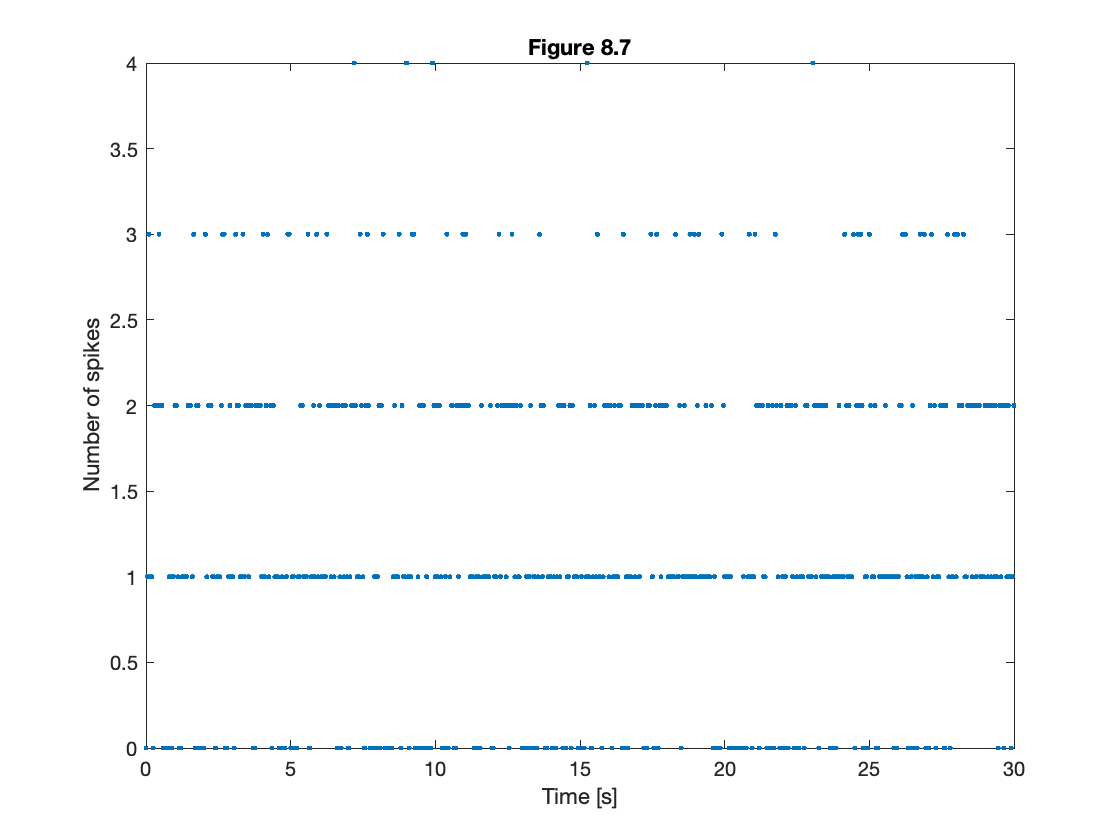

In [28]:
time_bins = (0:0.05:30); %Define time bins, 50ms increments,
%... compute a histogram of spike time data,
IncrementsLow50 = hist(SpikesLow, time_bins);
%... and plot the resulting counts versus time,

figure
plot(time_bins, IncrementsLow50, '.')
ylabel('Number of spikes') %... with x-axis labelled,
xlabel('Time [s]') %... and y-axis labelled.
title('Figure 8.7')

### Figure 8.8 Fano Factor

FF50Low = 0.7186

ans = 601

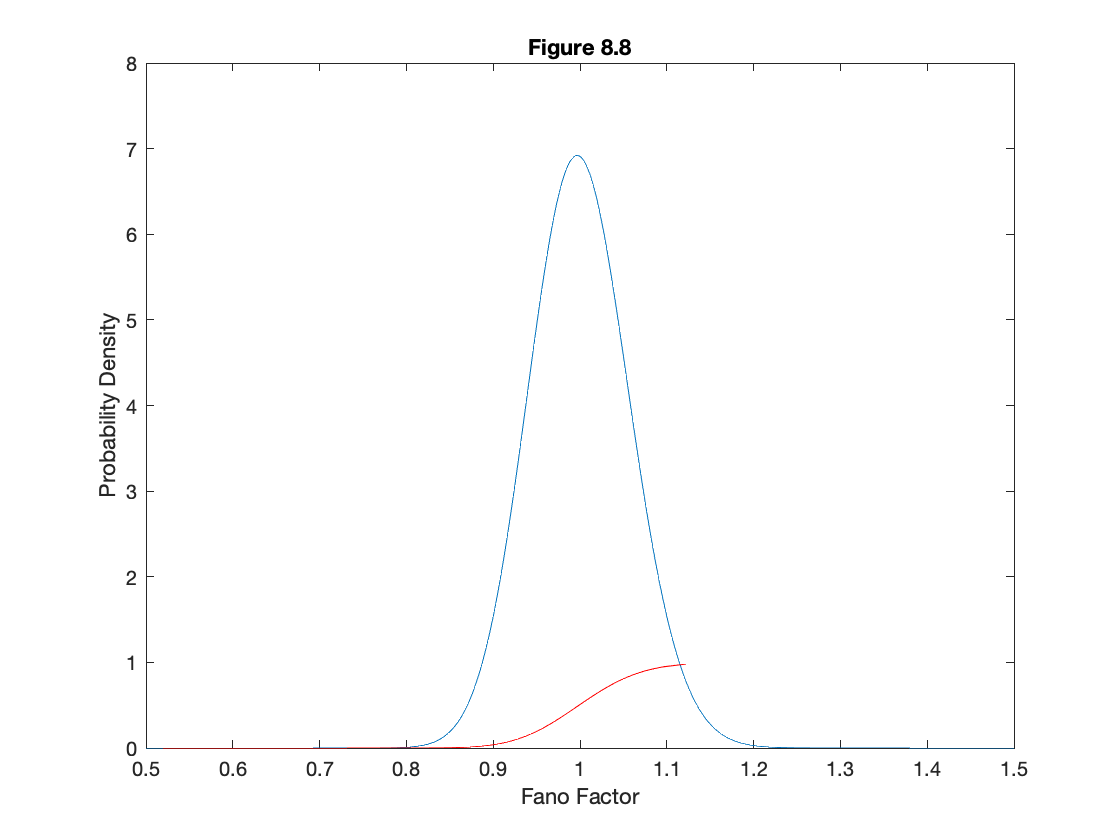

In [39]:
FF50Low = var(IncrementsLow50) / mean(IncrementsLow50)

length(IncrementsLow50)

N = length(IncrementsLow50); %Determine number of time bins.
FF = (0.5:0.001:1.5); %Define possible FF values for plot,
Y = gampdf(FF, (N - 1) / 2, 2 / (N - 1)); %... compute gamma distribution,

figure
plot(FF, Y); %... and plot it.
ylim([0, 8]) %... set y-axis range,
xlabel('Fano Factor') %... label the x-axis,
ylabel('Probability Density') %... and the y-axis.

pd = Y;
x = gaminv(pd, (N - 1) / 2, 2 / (N - 1));
hold on
plot(x, pd, 'r-', 'MarkerSize', 10)
title('Figure 8.8')


## Step 4

### Figure 8.11

ans = 1x7 double
    0.0132    0.0166    0.1022    1.0000    0.1022    0.0166    0.0132

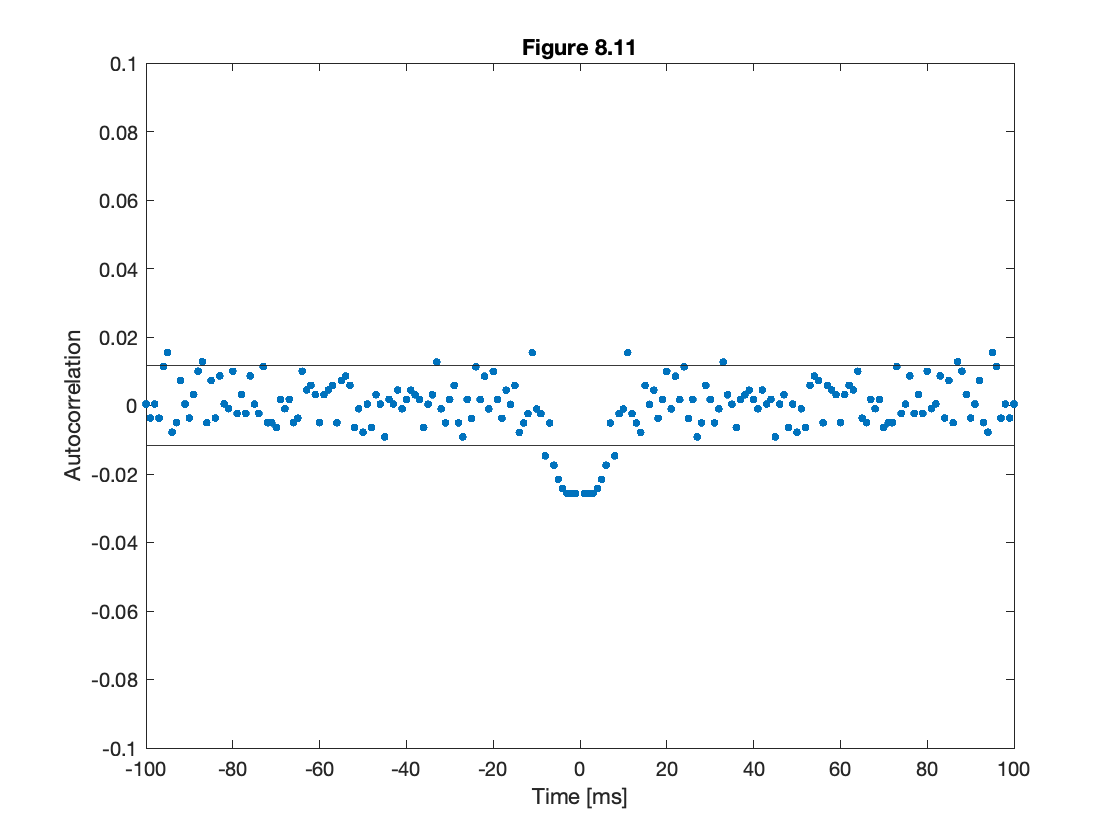

In [45]:
% Compute autocorrelation of increments process for low light.
xcorr(IncrementsLow50 - mean(IncrementsLow50), 3, 'coeff')

% Define time bins, 1 ms increments,
time_bins = (0:0.001:30);
% ... compute histogram to create increments process,
IncrementsLow1 = hist(SpikesLow, time_bins);
%... and then compute the autocorrelation function.
ACFLow = xcorr(IncrementsLow1 - mean(IncrementsLow1), 100, 'coeff');
N1 = length(IncrementsLow1); %... compute the sample size,

figure
plot(-100:100, ACFLow, '.', 'MarkerSize', 10) %Plot autocorrelation vs lags,
%... and plot the upper and lower significance lines,
yline([2 / sqrt(N1) 2 / sqrt(N1)])
yline(- [2 / sqrt(N1) 2 / sqrt(N1)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.11')


### Figure 8.12

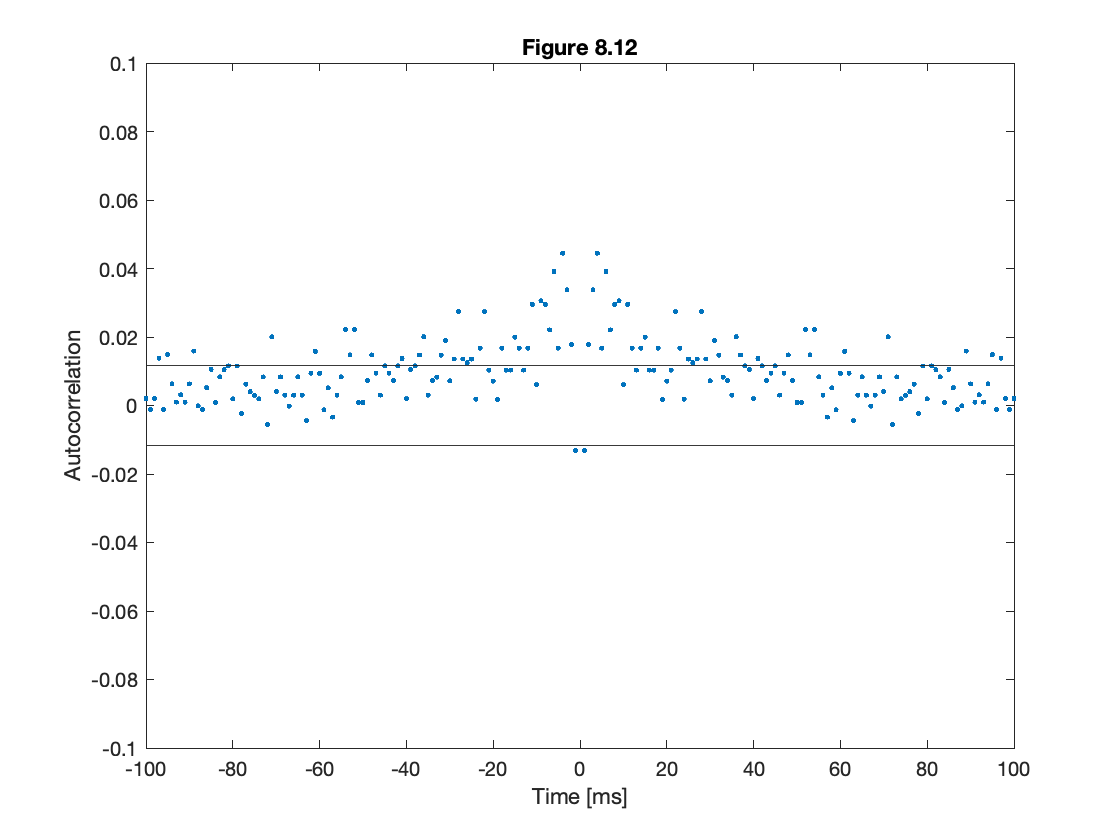

In [46]:
% Define time bins (1 ms increments), compute increments & ACF.
time_bins = (0:0.001:30);
IncrementsHigh1 = hist(SpikesHigh, time_bins);
ACFHigh = xcorr(IncrementsHigh1 - mean(IncrementsHigh1), 100, 'coeff');
N2 = length(IncrementsHigh1);

% Plot the autocorrelation vs lags with significance lines.
figure
plot(-100:100, ACFHigh, '.')
yline([2 / sqrt(N2) 2 / sqrt(N2)])
yline(- [2 / sqrt(N2) 2 / sqrt(N2)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.12')


### Figure 8.13

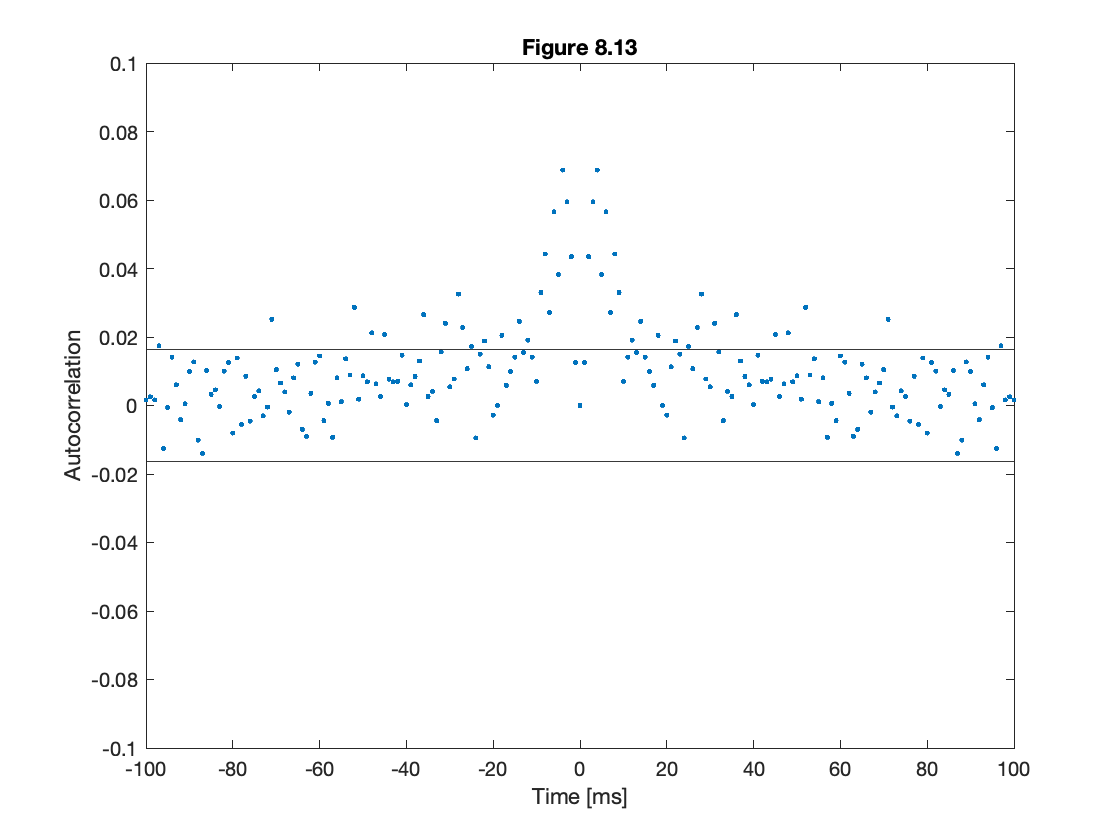

In [48]:
ACFDiff = ACFHigh - ACFLow; %Compute difference of autocorrelations,

% ... and plot it with upper and lower significance lines,
figure
plot(-100:100, ACFDiff, '.')
yline([2 * sqrt(1 / N1 + 1 / N2) 2 * sqrt(1 / N1 + 1 / N2)])
yline(- [2 * sqrt(1 / N1 + 1 / N2) 2 * sqrt(1 / N1 + 1 / N2)])
xlim([-100, 100]) %... set x-limits,
ylim([-0.1, 0.1]) %... and y-limits.
xlabel('Time [ms]')
ylabel('Autocorrelation')
title('Figure 8.13')
